# Random Descent vs Steepest Descent

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

# Ensure modules are reloaded on any change (very useful when developing code on the fly)
%load_ext autoreload
%autoreload 2

In [2]:
# Import external libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Import our code
from heur_sg import ShootAndGo
from objfun_recommender import Recommender

### Experiment setup

Runs selected objective function (`of`) using selected heuristic multiple times, stores and returns data (results) in a data frame.

In [3]:
def experiment(of, maxeval, num_runs, hmax, random_descent):
    method = 'RD' if random_descent else 'SD'
    results = []
    for i in tqdm(range(num_runs), 'Testing method={}, hmax={}'.format(method, hmax)):
        result = ShootAndGo(of, maxeval=maxeval, hmax=hmax, random_descent=random_descent, seed=i).search()
        result['run'] = i
        result['heur'] = 'SG_{}_{}'.format(method, hmax)
        result['method'] = method
        result['hmax'] = hmax
        results.append(result)

    return pd.DataFrame(results, columns=['heur', 'run', 'method', 'hmax', 'best_x', 'best_y', 'neval', 'success'])

In [4]:
NUM_RUNS = 10_000  # set to ~1k for first experiments

## Objective function: Recommender

2D discrete integer optimization on a [0, 99] × [0, 99] grid, with a global minimum at (37, 68) and two local traps.

In [5]:
recommender = Recommender()
num_states = int(np.prod(recommender.b - recommender.a + 1))
maxeval = int(num_states * 0.01)  # 1% of state space
print(f'num_states = {num_states:,}, maxeval = {maxeval}')

num_states = 10,000, maxeval = 100


## Experiments

#### Steepest Descent

In [6]:
table = pd.DataFrame()

for hmax in [0, 1, 2, 5, 10, 20, 50, np.inf]:
    res = experiment(of=recommender, maxeval=maxeval, num_runs=NUM_RUNS, hmax=hmax, random_descent=False)
    table = pd.concat([table, res], axis=0)

Testing method=SD, hmax=0:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=2:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=5:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=10:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=20:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=50:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=SD, hmax=inf:   0%|          | 0/10000 [00:00<?, ?it/s]

#### Random Descent

In [7]:
for hmax in [0, 1, 2, 5, 10, 20, 50, np.inf]:
    res = experiment(of=recommender, maxeval=maxeval, num_runs=NUM_RUNS, hmax=hmax, random_descent=True)
    table = pd.concat([table, res], axis=0)

Testing method=RD, hmax=0:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=1:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=2:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=5:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=10:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=20:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=50:   0%|          | 0/10000 [00:00<?, ?it/s]

Testing method=RD, hmax=inf:   0%|          | 0/10000 [00:00<?, ?it/s]

## Results analysis

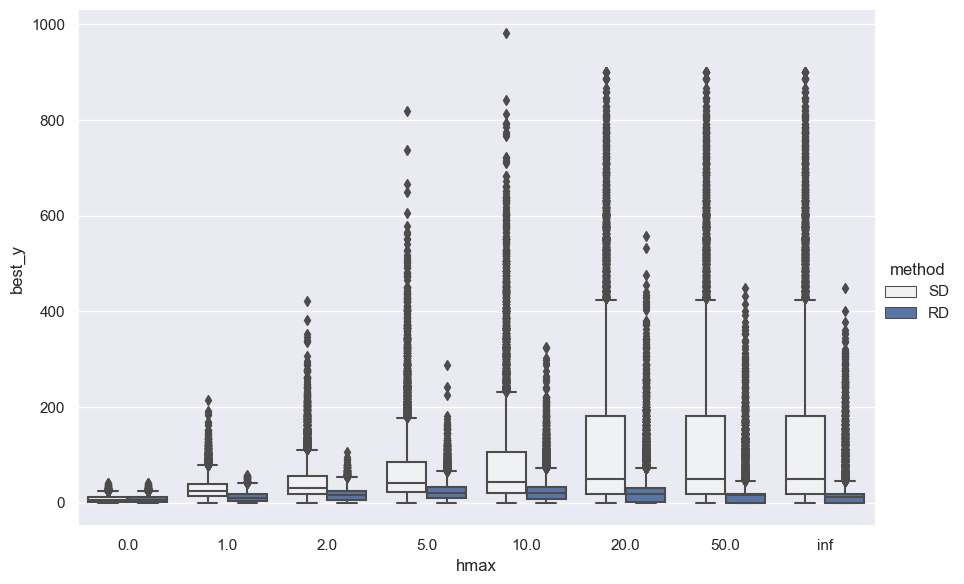

In [8]:
# define a stable order (explicitly include np.inf at the end)
hmax_order = [0.0, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, np.inf]

# set a stable method order
method_order = ["SD", "RD"] 

g = sns.FacetGrid(table, height=6, aspect=1.5)
ax = g.map(
    sns.boxplot,
    "hmax", "best_y", "method",
    order=hmax_order,
    hue_order=method_order
).add_legend(title="method")

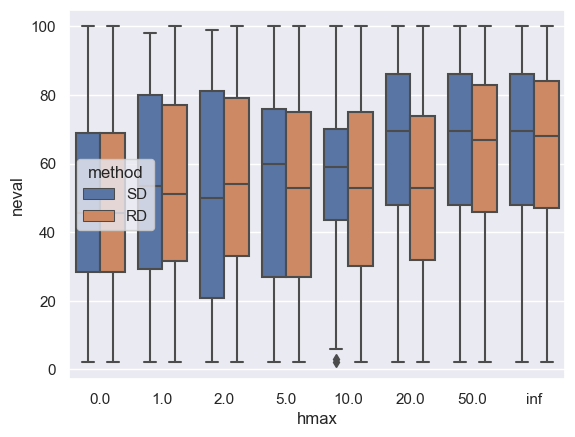

In [9]:
hmax_order = [0.0, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, np.inf]
method_order = ["SD", "RD"]

sns.boxplot(
    data=table[table["success"]],
    x="hmax", y="neval",
    hue="method",
    order=hmax_order,
    hue_order=method_order,
)
plt.legend(title="method");

In [10]:
stats = table.groupby(['hmax', 'method'])[['neval', 'success']].apply(
    lambda g: pd.Series({
        'rel': g['success'].mean(),
        'mne': g.loc[g['success'], 'neval'].mean(),
        'feo': g.loc[g['success'], 'neval'].mean() / g['success'].mean()
    })
).reset_index()

#### Reliability

#### Mean number of evaluations

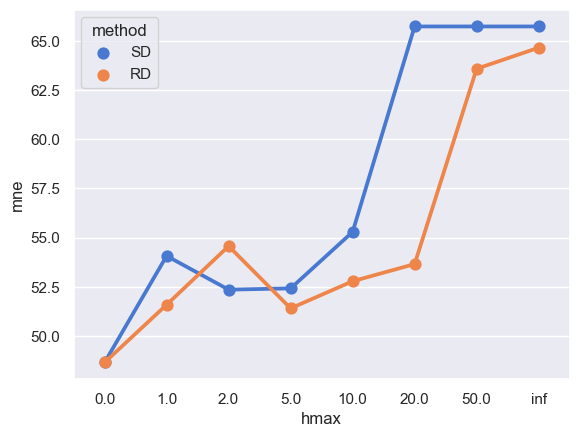

In [11]:
sns.pointplot(
    data=stats,
    x="hmax", y="mne",
    hue="method",
    order=hmax_order,
    hue_order=method_order,
    palette="muted"
);

#### Feoktistov criterion

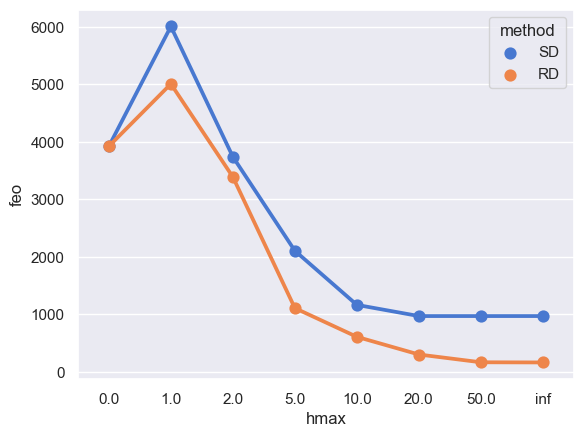

In [12]:
sns.pointplot(
    data=stats,
    x="hmax", y="feo",
    hue="method",
    order=hmax_order,
    hue_order=method_order,
    palette="muted"
);

## Conclusion

* At **hmax = 0** (pure Random Shooting), SD and RD are identical — no local search is performed, so the descent method is irrelevant.

* At **low hmax** (1–2), the two methods behave very similarly. The local search budget is too small for the choice of descent direction to matter much.

* At **higher hmax**, RD pulls significantly ahead in **reliability**: at hmax = 50, RD reaches ~38% vs SD's ~7%; at hmax = ∞, RD reaches ~40% while SD stays flat at ~7%.

* **SD plateaus after hmax = 20.** Steepest descent is fully deterministic given a starting point, so it always converges to the same local minimum from the same location. Once the descent converges (within ~20 steps on this landscape), adding more budget changes nothing.

* **RD keeps improving with hmax** because the random choice of descent direction means each run explores a different path through the neighbourhood — making it more likely to reach the global basin even from a starting point that would trap SD.

* The **MNE (mean evaluations when successful) is nearly identical** for both methods (~50–65). The difference is entirely in reliability, not in how quickly the optimum is found once within reach.

* The **Feoktistov criterion** captures this cleanly: FEO(RD, ∞) ≈ 163 vs FEO(SD, ∞) ≈ 970 — roughly **6× advantage for RD** on this objective function.

> **Takeaway:** on landscapes with local traps, random descent is a better default than steepest descent. The exhaustive neighbourhood evaluation of steepest descent is wasted effort if determinism causes repeated convergence to the same local minimum.